[![Open in colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nunososorio/SingleCellGenomics2024/blob/main/challenges/endothelial_cells_script_tutors.ipynb)


#### Non-small cell lung cancer (NSCLC) is histologically divided into adenocarcinoma, squamous cell carcinoma, and large-cell carcinoma. Lung adenocarcinoma (LUAD) is the most common type, accounting for approximately 40% of all lung cancers. LUAD is often detected at the metastatic stage with prevalence in the brain, bones, and respiratory system. Distant metastasis is the major cause of mortality in lung cancer; however, specific aspects of metastatic lung cancer and its associated microenvironments remain poorly understood.

#### Efforts made for the understanding of lung cancer progression and metastasis have largely focused on profiling of cancer cells with genetic aberrations. However, progression and metastasis are also influenced by complex and dynamic features in tumor surroundings.

#### To investigate stromal cell dynamics in the tumor microenvironment we will focus on endothelial cells. With the knowledge you already have in single cell analysis, determine de subclusters comprised in this endothelial population and if any of them are related to the tumor

#### Import scanpy, numpy, scipy, pandas, csv, matplotlib and seaborn libraries

In [ ]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install scanpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.4/122.4 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.8/79.8 kB 6.7 MB/s eta 0:00:00
  Created wheel for session-info: filename=session_info-1.0.0-py3-none-any.whl size=8026 sha256=69b3938ccfa76516b75e6f9a39fa8d52d82f8b9df3305cc493061c55f71eb392
  Stored in directory: /root/.cache/pip/wheels/6a/aa/b9/eb5d4031476ec10802795b97ccf937b9bd998d68a9b268765a
Successfully built session-info


In [ ]:
import scanpy as sc
import numpy as np
import scipy as sp
import pandas as pd
import csv as csv
import seaborn as sb

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colors
import gc

In [ ]:
from scipy import sparse
import os

### Read the files with raw data

In [ ]:
# Raw data
if not os.path.exists('endothelial_matrix_raw.h5ad'):
    !wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=13xNEUaOjvJU08O3gKYX2KkhjvWGGj9QX' -O endothelial_matrix_raw.h5ad

--2024-05-13 12:50:42--  https://docs.google.com/uc?export=download&id=13xNEUaOjvJU08O3gKYX2KkhjvWGGj9QX
Resolving docs.google.com (docs.google.com)... 173.194.215.138, 173.194.215.100, 173.194.215.101, ...
Connecting to docs.google.com (docs.google.com)|173.194.215.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=13xNEUaOjvJU08O3gKYX2KkhjvWGGj9QX&export=download [following]
--2024-05-13 12:50:42--  https://drive.usercontent.google.com/download?id=13xNEUaOjvJU08O3gKYX2KkhjvWGGj9QX&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.213.132, 2607:f8b0:400c:c0a::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.213.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28960896 (28M) [application/octet-stream]
Saving to: ‘endothelial_matrix_raw.h5ad’

endothelial_matrix_ 100%[===================>]  27

In [ ]:
adata = sc.read_h5ad('./endothelial_matrix_raw.h5ad')

#### What information do we have in this anndata object?

In [ ]:
adata

AnnData object with n_obs × n_vars = 1996 × 29634
    obs: 'Index', 'Barcode', 'Sample', 'Sample_Origin', 'Cell_type', 'Cell_type.refined', 'Cell_subtype'
    var: 'var_names'

In [ ]:
adata.obs

,Index,Barcode,Sample,Sample_Origin,Cell_type,Cell_type.refined,Cell_subtype
AGTCTTTGTGACTCAT_LUNG_N01,AGTCTTTGTGACTCAT_LUNG_N01,AGTCTTTGTGACTCAT,LUNG_N01,nLung,Endothelial cells,Endothelial cells,Tip-like ECs
ATCACGACAAGCGCTC_LUNG_N01,ATCACGACAAGCGCTC_LUNG_N01,ATCACGACAAGCGCTC,LUNG_N01,nLung,Endothelial cells,Endothelial cells,Tip-like ECs
CACAAACAGAAGGCCT_LUNG_N01,CACAAACAGAAGGCCT_LUNG_N01,CACAAACAGAAGGCCT,LUNG_N01,nLung,Endothelial cells,Endothelial cells,Tip-like ECs
CAGGTGCAGAGACTAT_LUNG_N01,CAGGTGCAGAGACTAT_LUNG_N01,CAGGTGCAGAGACTAT,LUNG_N01,nLung,Endothelial cells,Endothelial cells,Tip-like ECs
CATTCGCAGGCATGTG_LUNG_N01,CATTCGCAGGCATGTG_LUNG_N01,CATTCGCAGGCATGTG,LUNG_N01,nLung,Endothelial cells,Endothelial cells,Tip-like ECs
...,...,...,...,...,...,...,...
TATCAGGGTCAAACTC_LUNG_T34,TATCAGGGTCAAACTC_LUNG_T34,TATCAGGGTCAAACTC,LUNG_T34,tLung,Endothelial cells,Endothelial cells,Stalk-like ECs
TGGACGCTCATGGTCA_LUNG_T34,TGGACGCTCATGGTCA_LUNG_T34,TGGACGCTCATGGTCA,LUNG_T34,tLung,Endothelial cells,Endothelial cells,Stalk-like ECs
ACTTGTTCAGCTGTGC_LUNG_T34,ACTTGTTCAGCTGTGC_LUNG_T34,ACTTGTTCAGCTGTGC,LUNG_T34,tLung,Endothelial cells,Endothelial cells,Lymphatic ECs
CCTTCGATCATACGGT_LUNG_T34,CCTTCGATCATACGGT_LUNG_T34,CCTTCGATCATACGGT,LUNG_T34,tLung,Endothelial cells,Endothelial cells,Lymphatic ECs


In [ ]:
adata.var

,var_names
A1BG,A1BG
A1BG-AS1,A1BG-AS1
A1CF,A1CF
A2M,A2M
A2M-AS1,A2M-AS1
...,...
ZYX,ZYX
ZZEF1,ZZEF1
ZZZ3,ZZZ3
bP-21264C1.2,bP-21264C1.2


### Quality Control

In [ ]:
adata.obs

,Index,Barcode,Sample,Sample_Origin,Cell_type,Cell_type.refined,Cell_subtype
AGTCTTTGTGACTCAT_LUNG_N01,AGTCTTTGTGACTCAT_LUNG_N01,AGTCTTTGTGACTCAT,LUNG_N01,nLung,Endothelial cells,Endothelial cells,Tip-like ECs
ATCACGACAAGCGCTC_LUNG_N01,ATCACGACAAGCGCTC_LUNG_N01,ATCACGACAAGCGCTC,LUNG_N01,nLung,Endothelial cells,Endothelial cells,Tip-like ECs
CACAAACAGAAGGCCT_LUNG_N01,CACAAACAGAAGGCCT_LUNG_N01,CACAAACAGAAGGCCT,LUNG_N01,nLung,Endothelial cells,Endothelial cells,Tip-like ECs
CAGGTGCAGAGACTAT_LUNG_N01,CAGGTGCAGAGACTAT_LUNG_N01,CAGGTGCAGAGACTAT,LUNG_N01,nLung,Endothelial cells,Endothelial cells,Tip-like ECs
CATTCGCAGGCATGTG_LUNG_N01,CATTCGCAGGCATGTG_LUNG_N01,CATTCGCAGGCATGTG,LUNG_N01,nLung,Endothelial cells,Endothelial cells,Tip-like ECs
...,...,...,...,...,...,...,...
TATCAGGGTCAAACTC_LUNG_T34,TATCAGGGTCAAACTC_LUNG_T34,TATCAGGGTCAAACTC,LUNG_T34,tLung,Endothelial cells,Endothelial cells,Stalk-like ECs
TGGACGCTCATGGTCA_LUNG_T34,TGGACGCTCATGGTCA_LUNG_T34,TGGACGCTCATGGTCA,LUNG_T34,tLung,Endothelial cells,Endothelial cells,Stalk-like ECs
ACTTGTTCAGCTGTGC_LUNG_T34,ACTTGTTCAGCTGTGC_LUNG_T34,ACTTGTTCAGCTGTGC,LUNG_T34,tLung,Endothelial cells,Endothelial cells,Lymphatic ECs
CCTTCGATCATACGGT_LUNG_T34,CCTTCGATCATACGGT_LUNG_T34,CCTTCGATCATACGGT,LUNG_T34,tLung,Endothelial cells,Endothelial cells,Lymphatic ECs


In [ ]:
# Quality control - calculate QC covariates
adata.obs['n_counts'] = adata.X.sum(1)
adata.obs['log_counts'] = np.log(adata.obs['n_counts'])
adata.obs['n_genes'] = (adata.X > 0).sum(1)

In [ ]:
# QC covariates related to mitochondrial genes
mito_genes = [gene for gene in adata.var_names if gene.startswith('MT-')]
adata.obs['mito_counts'] = adata[:, mito_genes].X.sum(axis=1)
adata.obs['mt_frac'] = adata.obs['mito_counts'] / adata.obs['n_counts']

In [ ]:
# Different way to do it
sc.pp.calculate_qc_metrics(adata, inplace=True)

In [ ]:
adata.obs

,Index,Barcode,Sample,Sample_Origin,Cell_type,Cell_type.refined,Cell_subtype,n_counts,log_counts,n_genes,mito_counts,mt_frac,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
AGTCTTTGTGACTCAT_LUNG_N01,AGTCTTTGTGACTCAT_LUNG_N01,AGTCTTTGTGACTCAT,LUNG_N01,nLung,Endothelial cells,Endothelial cells,Tip-like ECs,1848.0,7.521859,1009,40.0,0.021645,1009,6.917706,1848.0,7.522400,32.251082,41.450216,53.246753,72.456710
ATCACGACAAGCGCTC_LUNG_N01,ATCACGACAAGCGCTC_LUNG_N01,ATCACGACAAGCGCTC,LUNG_N01,nLung,Endothelial cells,Endothelial cells,Tip-like ECs,8953.0,9.099744,3013,254.0,0.028370,3013,8.011023,8953.0,9.099855,26.739640,35.842734,46.811125,62.169105
CACAAACAGAAGGCCT_LUNG_N01,CACAAACAGAAGGCCT_LUNG_N01,CACAAACAGAAGGCCT,LUNG_N01,nLung,Endothelial cells,Endothelial cells,Tip-like ECs,1912.0,7.555905,1056,19.0,0.009937,1056,6.963190,1912.0,7.556428,32.635983,41.213389,52.092050,70.920502
CAGGTGCAGAGACTAT_LUNG_N01,CAGGTGCAGAGACTAT_LUNG_N01,CAGGTGCAGAGACTAT,LUNG_N01,nLung,Endothelial cells,Endothelial cells,Tip-like ECs,1332.0,7.194437,818,25.0,0.018769,818,6.708084,1332.0,7.195188,33.183183,41.741742,53.603604,76.126126
CATTCGCAGGCATGTG_LUNG_N01,CATTCGCAGGCATGTG_LUNG_N01,CATTCGCAGGCATGTG,LUNG_N01,nLung,Endothelial cells,Endothelial cells,Tip-like ECs,1166.0,7.061335,703,36.0,0.030875,703,6.556778,1166.0,7.062191,34.219554,44.082333,56.861063,82.590051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TATCAGGGTCAAACTC_LUNG_T34,TATCAGGGTCAAACTC_LUNG_T34,TATCAGGGTCAAACTC,LUNG_T34,tLung,Endothelial cells,Endothelial cells,Stalk-like ECs,6923.0,8.842605,1970,178.0,0.025711,1970,7.586296,6923.0,8.842749,38.697097,54.225047,64.581829,76.296403
TGGACGCTCATGGTCA_LUNG_T34,TGGACGCTCATGGTCA_LUNG_T34,TGGACGCTCATGGTCA,LUNG_T34,tLung,Endothelial cells,Endothelial cells,Stalk-like ECs,4364.0,8.381145,1620,77.0,0.017644,1620,7.390799,4364.0,8.381373,30.087076,42.873511,56.301558,73.441797
ACTTGTTCAGCTGTGC_LUNG_T34,ACTTGTTCAGCTGTGC_LUNG_T34,ACTTGTTCAGCTGTGC,LUNG_T34,tLung,Endothelial cells,Endothelial cells,Lymphatic ECs,3990.0,8.291547,1631,122.0,0.030576,1631,7.397562,3990.0,8.291797,30.802005,42.556391,54.937343,71.629073
CCTTCGATCATACGGT_LUNG_T34,CCTTCGATCATACGGT_LUNG_T34,CCTTCGATCATACGGT,LUNG_T34,tLung,Endothelial cells,Endothelial cells,Lymphatic ECs,4206.0,8.344268,1556,111.0,0.026391,1556,7.350516,4206.0,8.344505,33.880171,46.980504,59.201141,74.893010


In [ ]:
import matplotlib.pyplot as plt

<ipython-input-16-f7d51541c58f>:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)


<Figure size 3000x500 with 0 Axes>

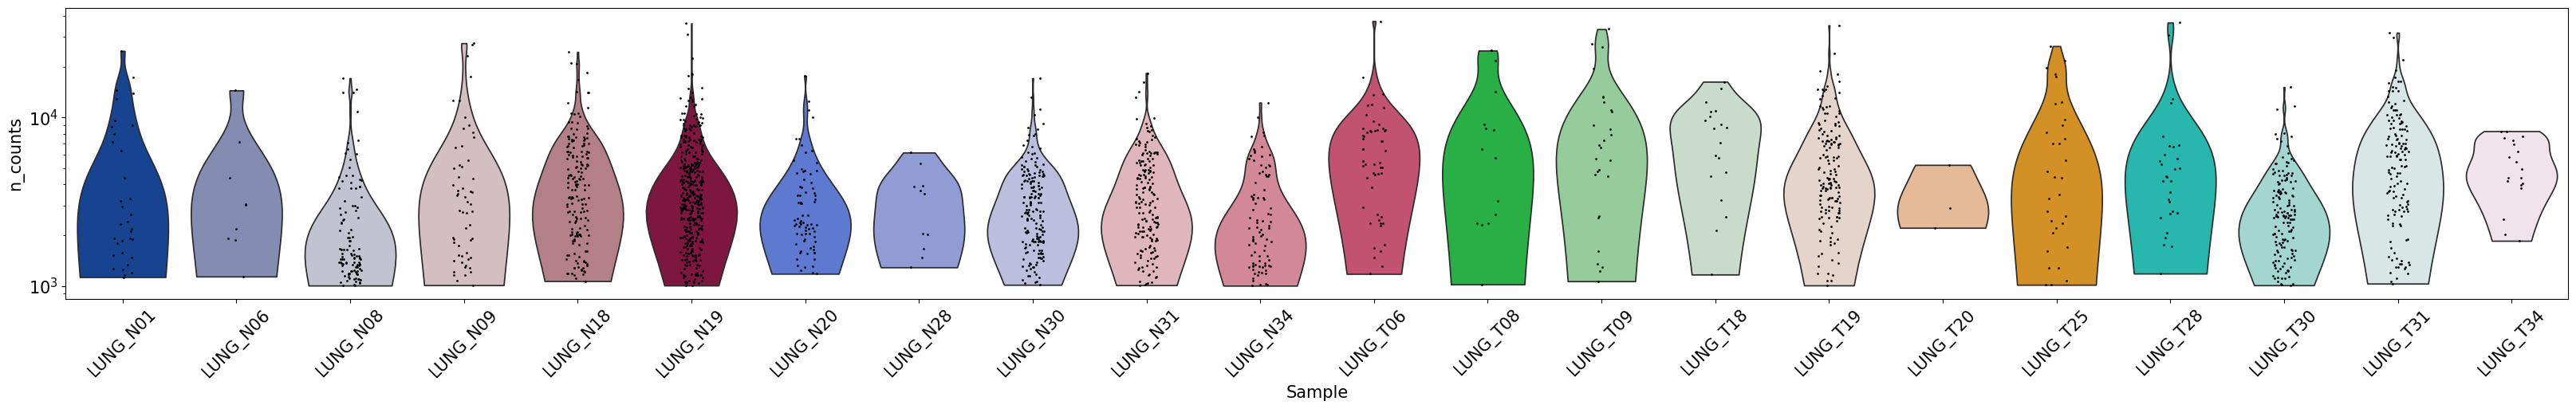

In [ ]:
# Quality control - plot QC metrics
# n_counts per Sample quality plots
plt.rcParams['figure.figsize'] = [30,5]
plt.rcParams['font.size'] = '15'
plt.figure()
sc.pl.violin(adata, 'n_counts', groupby='Sample', size=2, log=True, cut=0, show=False)
ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
plt.show()

<ipython-input-17-247c967d7ce7>:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)


<Figure size 3000x500 with 0 Axes>

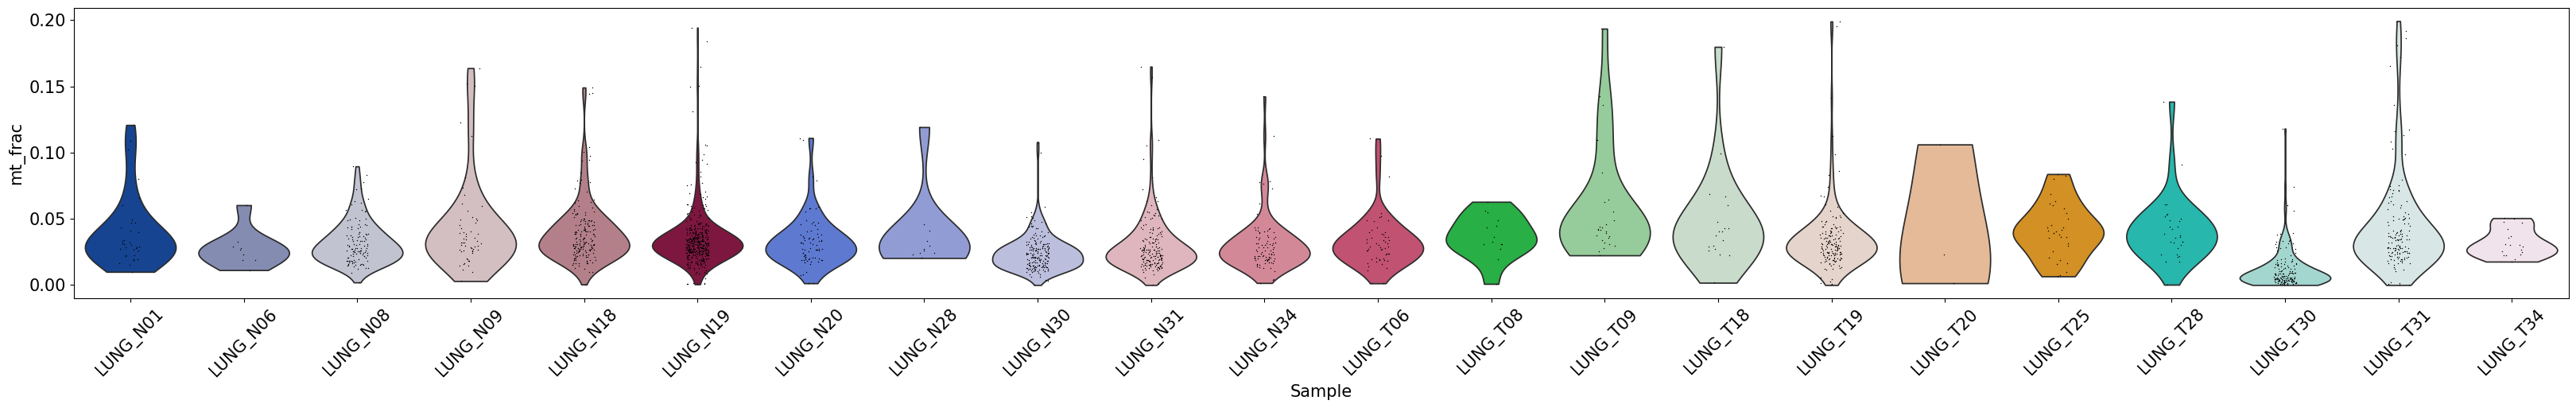

In [ ]:
# Mitochondrial fraction per sample quality plots
plt.rcParams['figure.figsize'] = [30,5]
plt.figure()
sc.pl.violin(adata, 'mt_frac', groupby='Sample', show = False)
ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
plt.show()

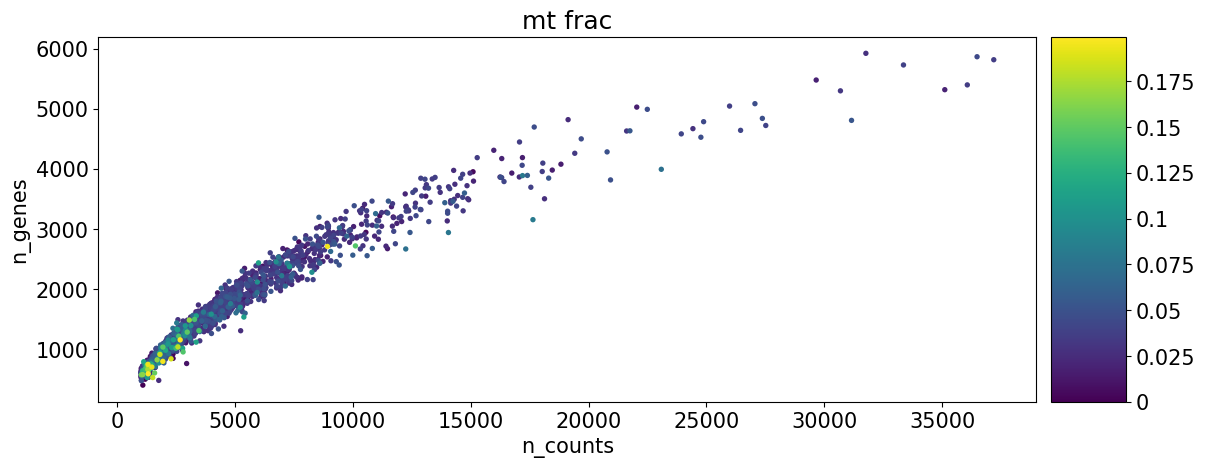

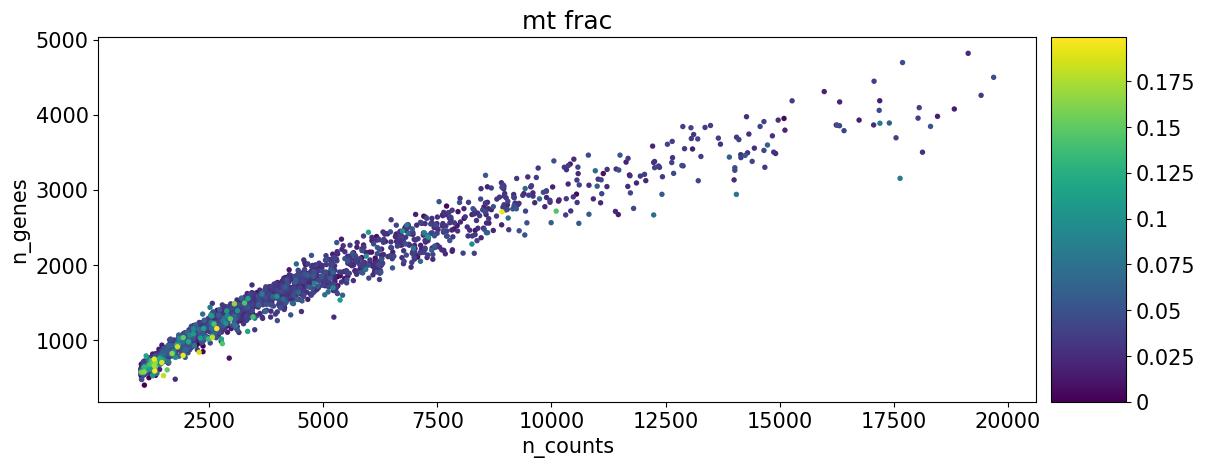

In [ ]:
#Data quality summary plots
plt.rcParams['figure.figsize'] = [10,5]
p1 = sc.pl.scatter(adata, 'n_counts', 'n_genes', color='mt_frac')
p2 = sc.pl.scatter(adata[adata.obs['n_counts']<20000], 'n_counts', 'n_genes', color='mt_frac')

In [ ]:
import warnings
warnings.filterwarnings('ignore')

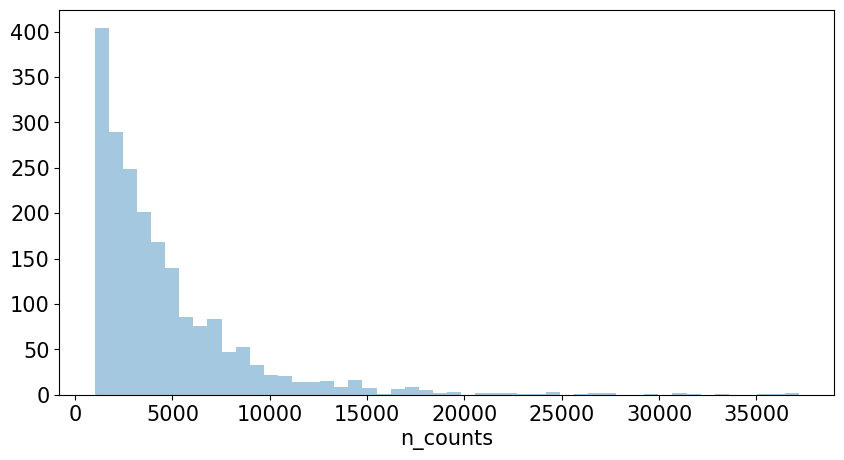

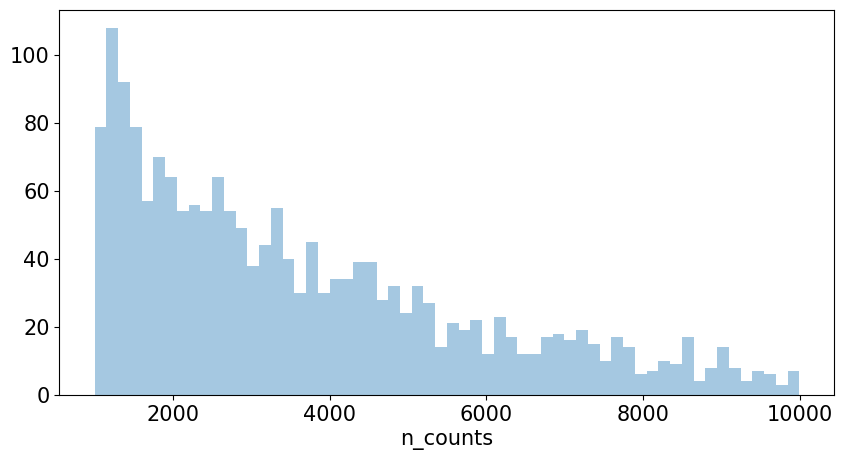

In [ ]:
#Thresholding decision: counts
p3 = sb.distplot(adata.obs['n_counts'], kde=False)
plt.show()

p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)
plt.show()

#p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>40000], kde=False, bins=60)
#plt.axvline(x = 90000, color = 'r', linestyle = '--')

plt.show()

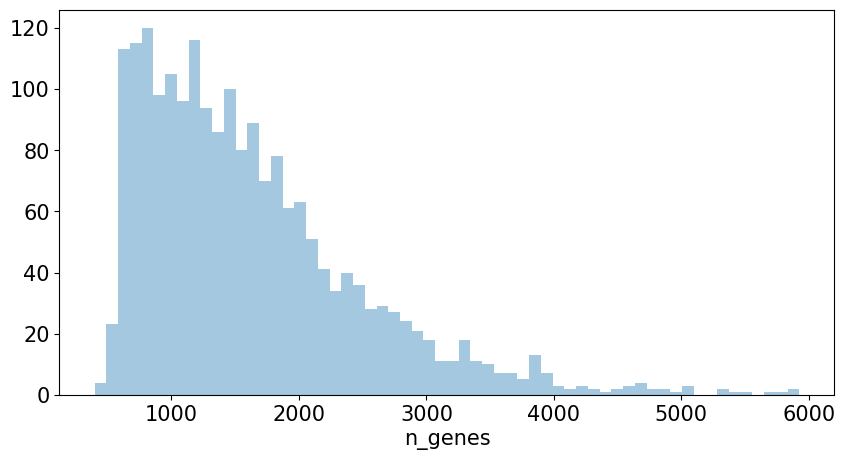

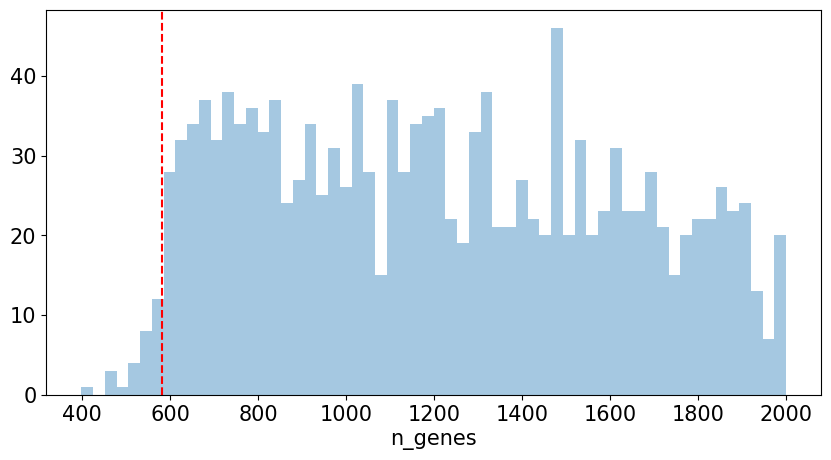

In [ ]:
#Thresholding decision: genes
p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)
plt.show()

p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes']<2000], kde=False, bins=60)
plt.axvline(x = 580, color = 'r', linestyle = '--')
plt.show()

In [ ]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

# sc.pp.filter_cells(adata, min_counts = 1000) Already filtered previously!
print('Number of cells after min count filter: {:d}'.format(adata.n_obs))

# sc.pp.filter_cells(adata, max_counts = 90000) # Not neccesary because this subset satisfies the cutoffs
print('Number of cells after max count filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['mt_frac'] < 0.2] # We can decrease to 0.15
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes = 600)
print('Number of cells after gene filter: {:d}'.format(adata.n_obs))

Total number of cells: 1996
Number of cells after min count filter: 1996
Number of cells after max count filter: 1996
Number of cells after MT filter: 1996
Number of cells after gene filter: 1953


In [ ]:
# Filtering genes
prefilter_var = int(adata.n_vars)
print(f'Original number of genes:', prefilter_var)
sc.pp.filter_genes(adata, min_cells=10)
print(f'Number of genes after quality control:{adata.n_vars}')
print(f'Number of genes removed:', prefilter_var-adata.n_vars)

Original number of genes: 29634
Number of genes after quality control:13609
Number of genes removed: 16025


Doublets detection

In [ ]:
!pip install scrublet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for annoy: filename=annoy-1.17.3-cp310-cp310-linux_x86_64.whl size=552450 sha256=db328a16e4cd1e79a13b924b781ac7178d5044f2f799c2bcb56ecfe97c9cdf59
  Stored in directory: /root/.cache/pip/wheels/64/8a/da/f714bcf46c5efdcfcac0559e63370c21abe961c48e3992465a
Successfully built annoy


In [ ]:
import scrublet as scr

In [ ]:
scrub = scr.Scrublet(adata.X.tocsc(), expected_doublet_rate=0.06)
doublet_scores, predicted_doublets = scrub.scrub_doublets(min_counts=2,
                                                          min_cells=3,
                                                          min_gene_variability_pctl=85,
                                                          n_prin_comps=30)
adata.obs['Doublet_score']=doublet_scores
adata.obs['Predicted_doublet']=predicted_doublets

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.46
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 8.1%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 0.0%
Elapsed time: 5.9 seconds


In [ ]:
adata.obs['Doublet_Threshold']=scrub.threshold_

In [ ]:
print(adata.obs['Predicted_doublet'].value_counts())
print('\nWe do not find any doublets!')

Predicted_doublet
False    1953
Name: count, dtype: int64

We do not find any doublets!


### Normalization

In [ ]:
adata.layers['counts'] = adata.X

In [ ]:
print(adata.X.max())

3777.0


In [ ]:
#Perform a clustering for scran normalization in clusters
import  gc
gc.collect()
sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e6)
sc.pp.log1p(adata)
gc.collect()

233

In [ ]:
print(adata.X.max())

12.832525


### Read the files  barcode.csv, varnames.csv and matrix.gz (normalized one)

In [ ]:
# Normalized data, barcodes metadata, genes metadata
if not os.path.exists('endothelial_matrix.npz'):
    !wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1AWnvjuruSjZgUOYP86ZkrACU3YAZ1j4f' -O endothelial_matrix.npz
if not os.path.exists('endothelial_barcodes.csv'):
    !wget https://raw.githubusercontent.com/nunososorio/SingleCellGenomics2024/main/challenges/endothelial_barcodes.csv
if not os.path.exists('endothelial_varnames.csv'):
    !wget https://raw.githubusercontent.com/nunososorio/SingleCellGenomics2024/main/challenges/endothelial_varnames.csv

--2024-05-13 12:52:01--  https://docs.google.com/uc?export=download&id=1AWnvjuruSjZgUOYP86ZkrACU3YAZ1j4f
Resolving docs.google.com (docs.google.com)... 173.194.215.139, 173.194.215.138, 173.194.215.113, ...
Connecting to docs.google.com (docs.google.com)|173.194.215.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1AWnvjuruSjZgUOYP86ZkrACU3YAZ1j4f&export=download [following]
--2024-05-13 12:52:01--  https://drive.usercontent.google.com/download?id=1AWnvjuruSjZgUOYP86ZkrACU3YAZ1j4f&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.213.132, 2607:f8b0:400c:c0a::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.213.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7626611 (7.3M) [application/octet-stream]
Saving to: ‘endothelial_matrix.npz’

endothelial_matrix. 100%[===================>]   7.27M 

In [ ]:
matrix = sparse.load_npz('endothelial_matrix.npz')
barcodes = pd.read_csv('/content/endothelial_barcodes.csv')
varnames = pd.read_csv('endothelial_varnames.csv')

#### Create the anndata object

In [ ]:
adata = sc.AnnData(X=matrix, obs=barcodes, var=varnames)

In [ ]:
adata.obs_names = list(adata.obs['obs_names'])
adata.var_names = list(adata.var['var_names'])

In [ ]:
adata.obs['origin'].astype('category').value_counts()

origin
nLung     1295
tLung      627
mBrain     159
tL/B        18
mLN          8
Name: count, dtype: int64

##### How many cells and genes do we have?

In [ ]:
adata.n_obs

2107

In [ ]:
adata.n_vars

20599

##### How many samples do we have?

In [ ]:
adata.obs['sample'] = adata.obs['sample'].astype('category')

In [ ]:
len(adata.obs['sample'].cat.categories)

36

##### Which is the sample with more number of cells? And with lower?

In [ ]:
adata.obs['sample'].value_counts()

sample
LUNG_N19      395
LUNG_N30      180
LUNG_N18      173
LUNG_N31      164
LUNG_T19      159
LUNG_T30      145
LUNG_T31      135
LUNG_N08      112
LUNG_N34       88
LUNG_N20       75
NS_04          58
LUNG_N09       57
LUNG_T06       51
LUNG_N01       32
LUNG_T25       30
LUNG_T28       29
LUNG_T09       28
NS_19          27
NS_07          24
NS_17          20
LUNG_T34       19
LUNG_T18       17
BRONCHO_58     12
LUNG_T08       12
NS_12          12
LUNG_N28       11
LUNG_N06        8
NS_03           7
NS_13           5
EBUS_10         4
EBUS_28         4
BRONCHO_11      4
NS_06           3
NS_16           3
EBUS_06         2
LUNG_T20        2
Name: count, dtype: int64

#### Determine HVGs. In this case, select as top genes the 10% of the total genes

In [ ]:
sc.pp.highly_variable_genes(adata, flavor='seurat', n_top_genes=int(adata.n_vars*0.1))
print('\n','Number of highly variable genes: {:d}'.format(np.sum(adata.var['highly_variable'])))


 Number of highly variable genes: 2059


### Dimensionality reduction

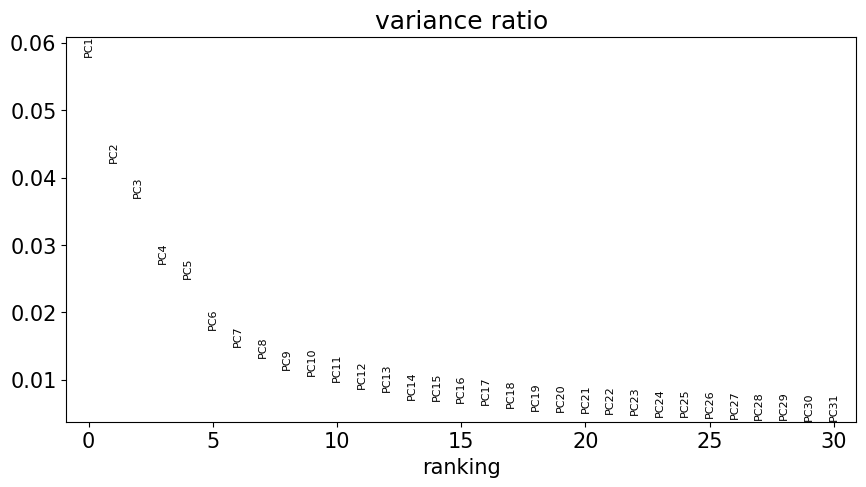

In [ ]:
sc.pp.pca(adata, n_comps=50, use_highly_variable=True, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=False)

In [ ]:
sc.pp.pca(adata, n_comps=15, use_highly_variable=True, svd_solver='arpack')

#### neighbors

##### Estimate neighbors with size of the local neighborhood = 10

In [ ]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=15)

### Dimensionality reduction (visualization)

In [ ]:
sc.tl.umap(adata, n_components=15, alpha=0.3, min_dist=0.5, random_state=42)
sc.tl.tsne(adata, n_pcs = 15)

In [ ]:
adata

AnnData object with n_obs × n_vars = 2107 × 20599
    obs: 'Unnamed: 0', 'Barcode', 'barcode', 'cellsubtype', 'celltype', 'celltype_refined', 'index', 'n_counts', 'obs_names', 'origin', 'sample'
    var: 'Unnamed: 0', 'dispersions', 'dispersions_norm', 'highly_variable', 'means', 'n_cells', 'var_names'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'tsne'
    obsm: 'X_pca', 'X_umap', 'X_tsne'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

##### Is there any bias related to sample origin? E.g: It seems like a group of cells from mLN samples cluster together

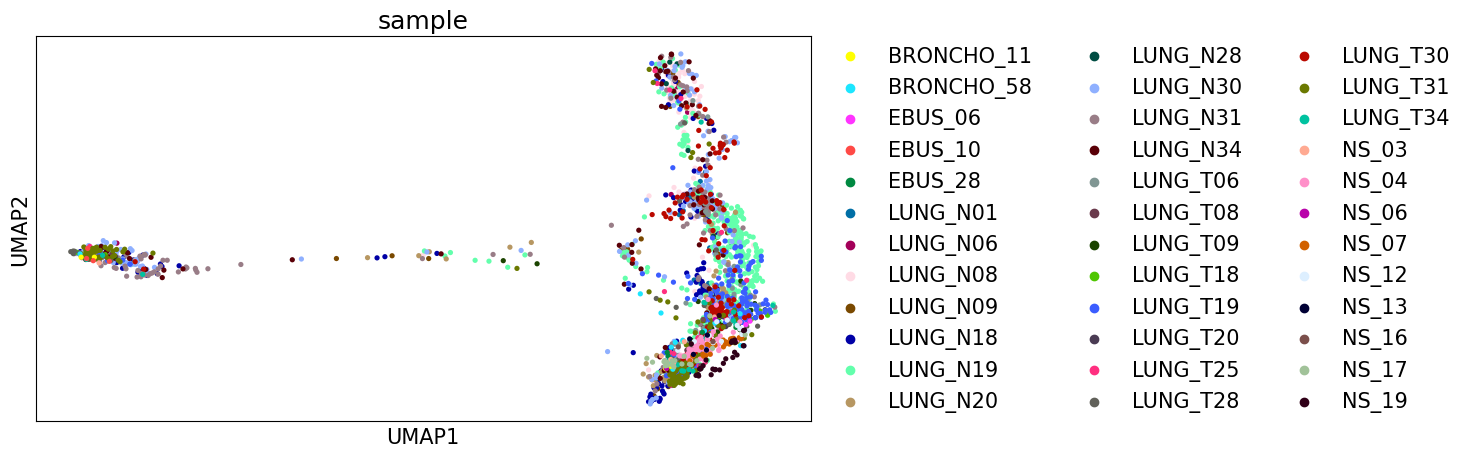

In [ ]:
plt.rcParams['figure.facecolor'] = 'white'
sc.pl.umap(adata, color = 'sample')

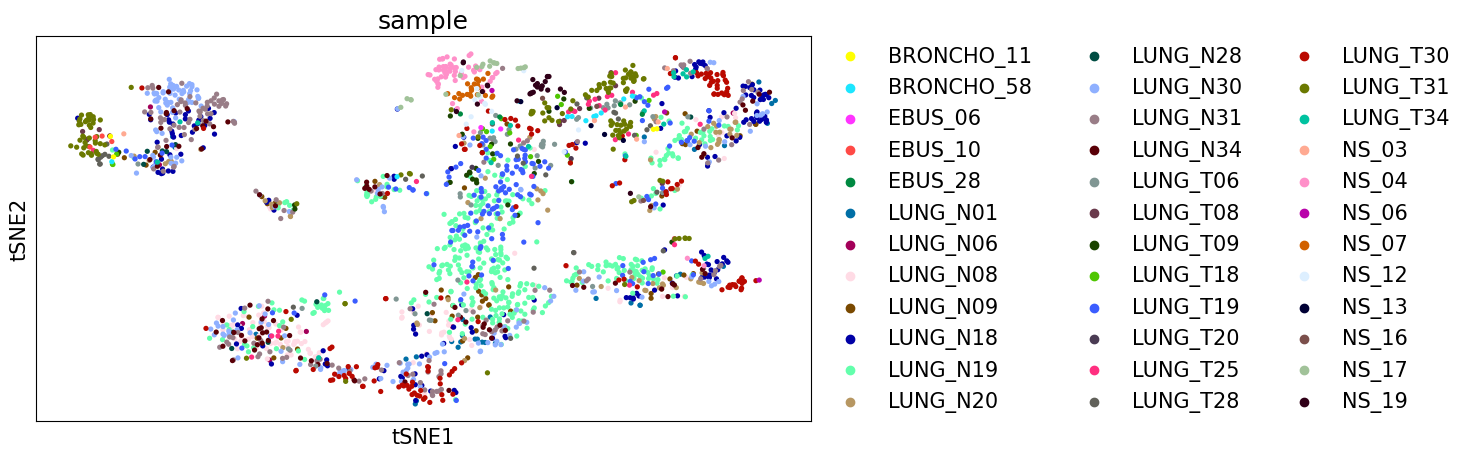

In [ ]:
sc.pl.tsne(adata, color = 'sample')

### Clustering

In [ ]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install igraph louvain


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 12.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.1 MB/s eta 0:00:00


In [ ]:
sc.tl.louvain(adata, resolution = 0.2, key_added = 'louvain2', random_state = 0) # resolution 0.1 y resolution 0.25

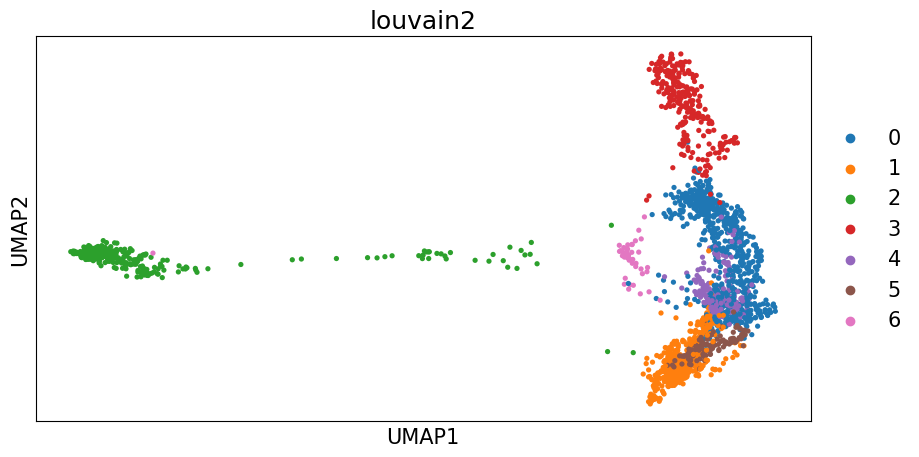

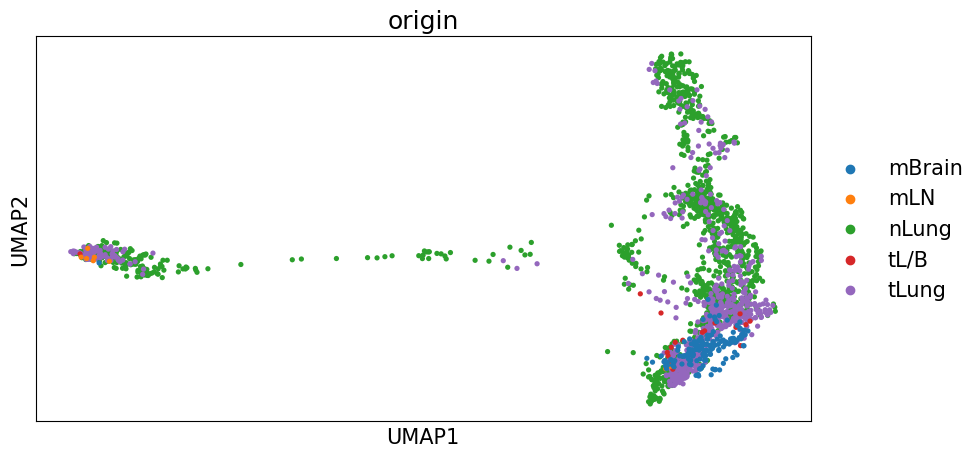

In [ ]:
sc.pl.umap(adata, color = 'louvain2')
sc.pl.umap(adata, color = 'origin')

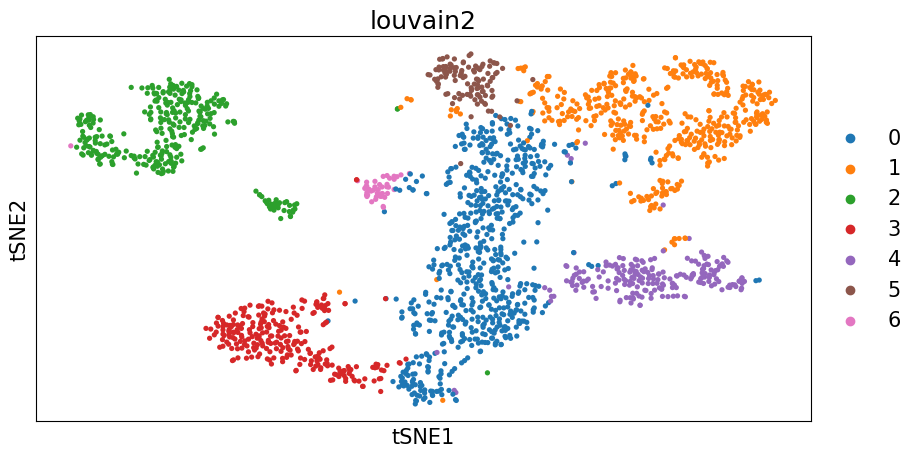

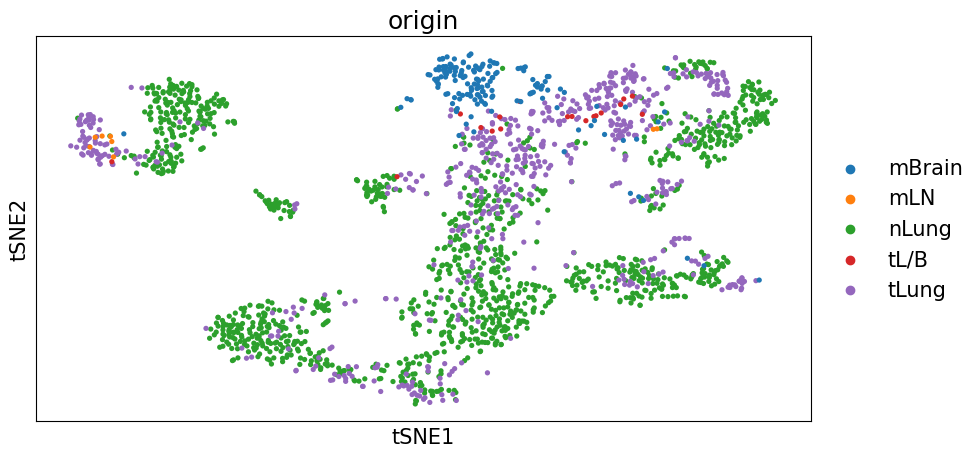

In [ ]:
sc.pl.tsne(adata, color = 'louvain2')
sc.pl.tsne(adata, color = 'origin')

In [ ]:
adata

AnnData object with n_obs × n_vars = 2107 × 20599
    obs: 'Unnamed: 0', 'Barcode', 'barcode', 'cellsubtype', 'celltype', 'celltype_refined', 'index', 'n_counts', 'obs_names', 'origin', 'sample', 'louvain2'
    var: 'Unnamed: 0', 'dispersions', 'dispersions_norm', 'highly_variable', 'means', 'n_cells', 'var_names'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'tsne', 'sample_colors', 'louvain2', 'louvain2_colors', 'origin_colors'
    obsm: 'X_pca', 'X_umap', 'X_tsne'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

##### Which is the cluster with more number of cells? How many does it have?

In [ ]:
adata.obs['louvain2'].value_counts()

louvain2
0    677
1    482
2    320
3    262
4    212
5    111
6     43
Name: count, dtype: int64

### Annotation

#### Determine the marker genes for each cluster

In [ ]:
sc.tl.rank_genes_groups(adata, groupby='louvain2', key_added='rank_genes_groups', method='wilcoxon', corr_method = 'benjamini-hochberg',
                        groups = 'all', reference = 'rest')

In [ ]:
gc.collect()

104365

##### Estimate the logfoldchanges for each marker in the resulting clusters and plot the top 10 markers for each one taking into account the logfoldchanges values

In [ ]:
cero_markers = sc.get.rank_genes_groups_df(adata, group='0', key='rank_genes_groups', pval_cutoff=1e-10, log2fc_min=0.5)
cero_markers['cluster'] = ['0']*len(cero_markers)

uno_markers = sc.get.rank_genes_groups_df(adata, group='1', key='rank_genes_groups', pval_cutoff=1e-10, log2fc_min=0.5)
uno_markers['cluster'] = ['1']*len(uno_markers)

dos_markers = sc.get.rank_genes_groups_df(adata, group='2', key='rank_genes_groups', pval_cutoff=1e-10, log2fc_min=0.5)
dos_markers['cluster'] = ['2']*len(dos_markers)

tres_markers = sc.get.rank_genes_groups_df(adata, group='3', key='rank_genes_groups', pval_cutoff=1e-10, log2fc_min=0.5)
tres_markers['cluster'] = ['3']*len(tres_markers)

cuatro_markers = sc.get.rank_genes_groups_df(adata, group='4', key='rank_genes_groups', pval_cutoff=1e-10, log2fc_min=0.5)
cuatro_markers['cluster'] = ['4']*len(cuatro_markers)

cinco_markers = sc.get.rank_genes_groups_df(adata, group='5', key='rank_genes_groups', pval_cutoff=1e-10, log2fc_min=0.5)
cinco_markers['cluster'] = ['5']*len(cinco_markers)

seis_markers = sc.get.rank_genes_groups_df(adata, group='6', key='rank_genes_groups', pval_cutoff=1e-10, log2fc_min=0.5)
seis_markers['cluster'] = ['6']*len(seis_markers)

### Select 'de novo' markers

##### Cluster number 0

In [ ]:
cero_markers.sort_values('logfoldchanges', ascending=False)

,names,scores,logfoldchanges,pvals,pvals_adj,cluster
0,FCN3,21.828159,4.971938,1.253671e-105,2.582437e-101,0
1,RGCC,21.785065,3.590615,3.214929e-105,3.311216e-101,0
13,IL7R,14.843740,3.588220,7.637569e-50,8.740349e-47,0
11,GPIHBP1,15.309430,3.129344,6.614114e-53,8.515258e-50,0
50,SLC6A4,9.468568,2.990324,2.837057e-21,7.214880e-19,0
...,...,...,...,...,...,...
26,H3F3A,11.869555,0.692082,1.703699e-32,9.485001e-30,0
72,ACTG1,8.466872,0.654348,2.520702e-17,4.476201e-15,0
46,HMGB1,9.770964,0.631969,1.500187e-22,4.162633e-20,0
67,HLA-E,8.882872,0.621063,6.515609e-19,1.315834e-16,0


##### Which are the top 3 markers for this cluster? (Taking into account the logfoldchange)

##### Heatmap with 3 best markers for each cluster

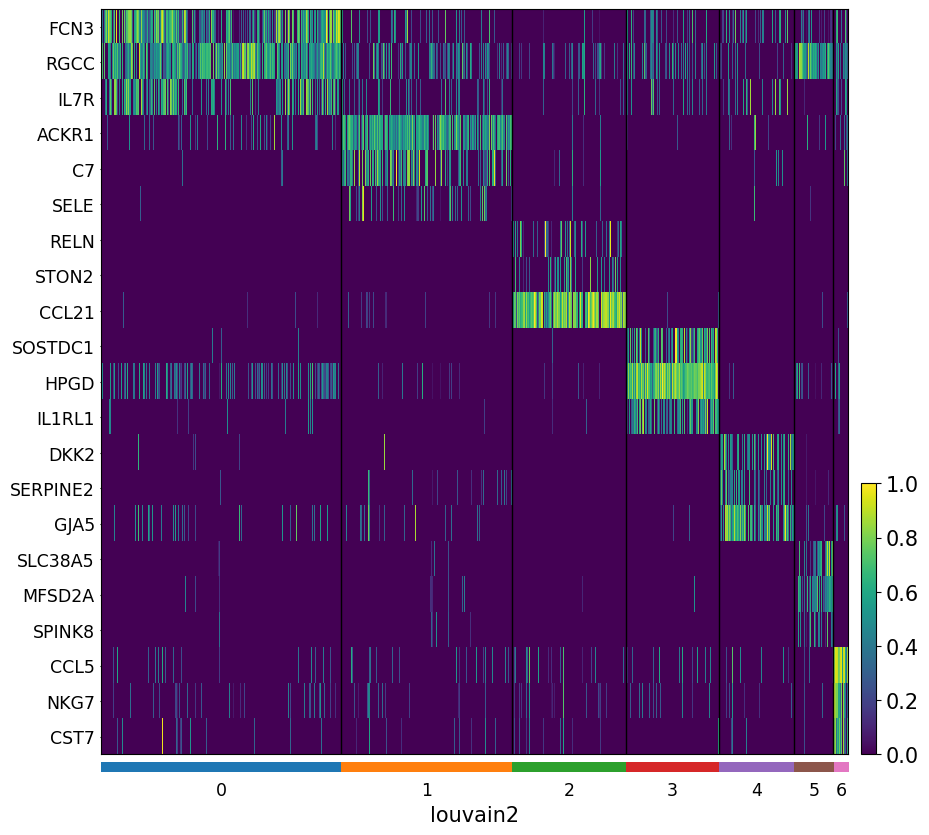

In [ ]:
sc.pl.heatmap(adata, list(cero_markers.sort_values('logfoldchanges', ascending=False).names[0:3])+
              list(uno_markers.sort_values('logfoldchanges', ascending=False).names[0:3])+
              list(dos_markers.sort_values('logfoldchanges', ascending=False).names[0:3])+
              list(tres_markers.sort_values('logfoldchanges', ascending=False).names[0:3])+
              list(cuatro_markers.sort_values('logfoldchanges', ascending=False).names[0:3])+
              list(cinco_markers.sort_values('logfoldchanges', ascending=False).names[0:3])+
              list(seis_markers.sort_values('logfoldchanges', ascending=False).names[0:3])
              , swap_axes=True,
              groupby = 'louvain2', standard_scale='var', figsize=[10,10])

### Markers highlighted in the original article

### Markers:
    Tumor cells: 'INSR','HSPG2','VWA1'
    Tip-like cells: 'RGCC','RAMP3','ADM'
    Stalk-like cells: 'ACKR1','SELP'
    EPCs: 'TYROBP','C1QB'
    Lymphatic: 'LYVE1','PROX1'

In [ ]:
markers = pd.concat([cero_markers, uno_markers, dos_markers, tres_markers, cuatro_markers, cinco_markers, seis_markers])

In [ ]:
markers[markers.names.str.contains('|'.join(['INSR','HSPG2','VWA1',
                                             'RGCC','RAMP3','ADM',
                                             'ACKR1','SELP',
                                             'TYROBP','C1QB',
                                             'LYVE1','PROX1']))]

,names,scores,logfoldchanges,pvals,pvals_adj,cluster
1,RGCC,21.785065,3.590615,3.214929e-105,3.311216e-101,0
0,ACKR1,27.157953,7.119814,2.039593e-162,4.201357e-158,1
16,HSPG2,14.445927,2.188098,2.659556e-47,2.608771e-44,1
20,SELP,13.940467,3.264275,3.595794e-44,2.554130e-41,1
75,RAMP3,10.298071,1.538975,7.188850e-25,1.526630e-22,1
9,PROX1,18.519579,7.802619,1.435536e-76,1.556347e-73,2
120,LYVE1,10.385641,2.469165,2.882255e-25,3.280198e-23,2
2,INSR,12.376835,4.633728,3.488281e-35,7.983900e-32,5
11,RGCC,10.545252,3.433777,5.342967e-26,5.240942e-23,5
14,VWA1,10.404675,3.555519,2.360604e-25,2.026087e-22,5


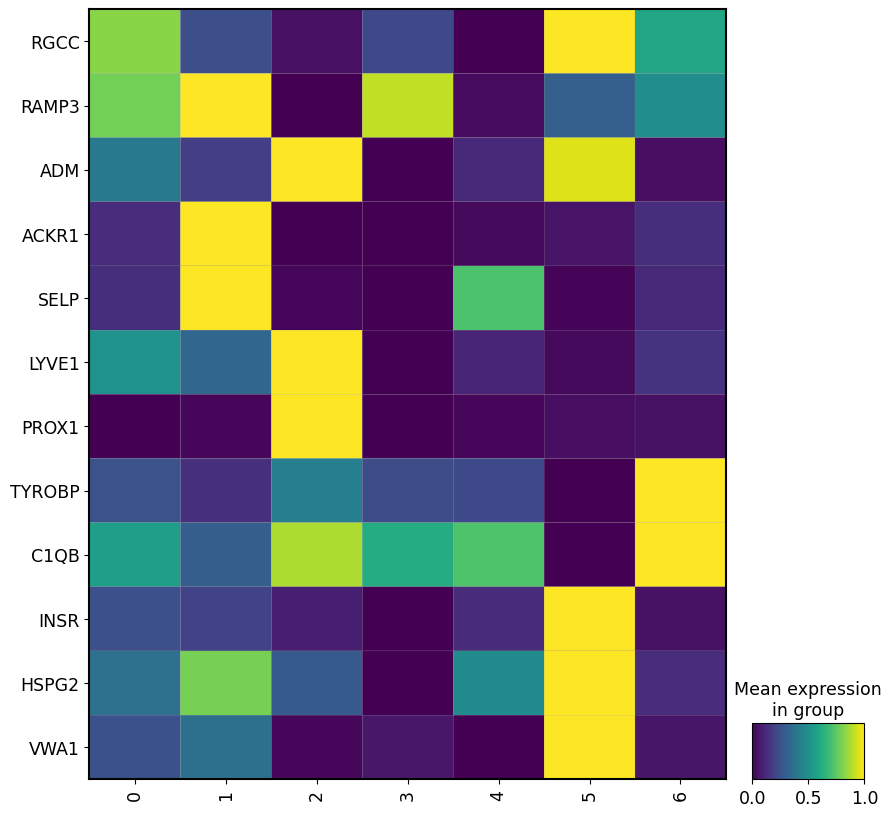

In [ ]:
sc.pl.matrixplot(adata, ['RGCC','RAMP3','ADM',
                         'ACKR1','SELP',
                         'LYVE1','PROX1',
                         'TYROBP','C1QB',
                         'INSR','HSPG2','VWA1'],
                 groupby='louvain2', swap_axes=True, figsize=[10,10], standard_scale='var')

##### Which cluster relates to Lympathic cells? And to EPCs?



GSEA with KEGG database

In [ ]:
!pip install gseapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.9/552.9 kB 6.7 MB/s eta 0:00:00


In [ ]:
import gseapy as gp

In [ ]:
matrix = adata[(adata.obs['louvain2']=='0')| (adata.obs['louvain2']=='3')].to_df().T
celltypes = adata[(adata.obs['louvain2']=='0')| (adata.obs['louvain2']=='3')].obs.louvain2

In [ ]:
import gc
gc.collect()

18030

In [ ]:
if not os.path.exists('kegg_pathways.gmt'):
    !wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1J5ZMGoRuCQct7TmN07MaVZC_nH4xnZfY' -O kegg_pathways.gmt

--2024-05-13 12:54:09--  https://docs.google.com/uc?export=download&id=1J5ZMGoRuCQct7TmN07MaVZC_nH4xnZfY
Resolving docs.google.com (docs.google.com)... 173.194.215.102, 173.194.215.139, 173.194.215.138, ...
Connecting to docs.google.com (docs.google.com)|173.194.215.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1J5ZMGoRuCQct7TmN07MaVZC_nH4xnZfY&export=download [following]
--2024-05-13 12:54:09--  https://drive.usercontent.google.com/download?id=1J5ZMGoRuCQct7TmN07MaVZC_nH4xnZfY&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.213.132, 2607:f8b0:400c:c0a::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.213.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84217 (82K) [application/octet-stream]
Saving to: ‘kegg_pathways.gmt’

kegg_pathways.gmt   100%[===================>]  82.24K  --.-KB/

In [ ]:
res_kegg = gp.gsea(data = matrix,
                   gene_sets='./kegg_pathways.gmt',
                   cls=list(celltypes),
                   permutation_num=100,
                   permutation_type='phenotype',
                   outdir=None,
                   method='s2n',
                   threads=4)

In [ ]:
res_kegg.res2d.sort_values('NES', ascending = False)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,gsea,KEGG_RIBOSOME,0.965942,2.718438,0.0,0.0,0.0,77/84,2.18%,RPS6;RPS24;RPS8;RPS18;RPL7A;RPS19;RPLP1;RPS3;R...
1,gsea,KEGG_CARDIAC_MUSCLE_CONTRACTION,0.673551,2.640162,0.0,0.0,0.0,22/50,14.14%,TPM1;MT-CYB;TPM4;ATP1B3;MT-CO1;UQCRH;MT-CO3;UQ...
2,gsea,KEGG_ADHERENS_JUNCTION,0.561405,2.543119,0.0,0.0,0.0,26/63,19.87%,PTPRB;INSR;ACTG1;FYN;TCF7L1;ACTN4;YES1;TGFBR2;...
3,gsea,KEGG_HUNTINGTONS_DISEASE,0.514862,2.490964,0.0,0.0,0.0,73/152,29.49%,TGM2;MT-CYB;AP2S1;MT-CO1;UQCRH;MT-CO3;UQCRQ;CO...
4,gsea,KEGG_OXIDATIVE_PHOSPHORYLATION,0.548549,2.462357,0.0,0.0,0.0,54/103,26.04%,MT-CYB;MT-ND4;MT-CO1;UQCRH;MT-CO3;UQCRQ;COX7C;...
...,...,...,...,...,...,...,...,...,...,...
14,gsea,KEGG_AUTOIMMUNE_THYROID_DISEASE,-0.783371,-2.178478,0.0,0.00082,0.01,14/27,5.68%,HLA-E;HLA-C;HLA-B;HLA-DRA;HLA-DQA1;HLA-DQA2;FA...
11,gsea,KEGG_ALLOGRAFT_REJECTION,-0.740441,-2.200795,0.0,0.001025,0.01,14/29,5.68%,HLA-E;HLA-C;HLA-B;HLA-DRA;HLA-DQA1;HLA-DQA2;FA...
10,gsea,KEGG_TYPE_I_DIABETES_MELLITUS,-0.703278,-2.244466,0.0,0.0,0.0,15/35,5.68%,HLA-E;HLA-C;HLA-B;HLA-DRA;HLA-DQA1;HLA-DQA2;FA...
9,gsea,KEGG_ANTIGEN_PROCESSING_AND_PRESENTATION,-0.629388,-2.260377,0.0,0.0,0.0,20/59,5.68%,B2M;HLA-E;HLA-C;HLA-B;CD74;HLA-DRA;HLA-DQA1;HL...


In [ ]:
res_kegg.res2d = res_kegg.res2d[res_kegg.res2d['FWER p-val'] < 0.05].sort_values('NES', ascending = False)

In [ ]:
res_kegg.res2d

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,gsea,KEGG_RIBOSOME,0.965942,2.718438,0.0,0.0,0.0,77/84,2.18%,RPS6;RPS24;RPS8;RPS18;RPL7A;RPS19;RPLP1;RPS3;R...
1,gsea,KEGG_CARDIAC_MUSCLE_CONTRACTION,0.673551,2.640162,0.0,0.0,0.0,22/50,14.14%,TPM1;MT-CYB;TPM4;ATP1B3;MT-CO1;UQCRH;MT-CO3;UQ...
2,gsea,KEGG_ADHERENS_JUNCTION,0.561405,2.543119,0.0,0.0,0.0,26/63,19.87%,PTPRB;INSR;ACTG1;FYN;TCF7L1;ACTN4;YES1;TGFBR2;...
3,gsea,KEGG_HUNTINGTONS_DISEASE,0.514862,2.490964,0.0,0.0,0.0,73/152,29.49%,TGM2;MT-CYB;AP2S1;MT-CO1;UQCRH;MT-CO3;UQCRQ;CO...
4,gsea,KEGG_OXIDATIVE_PHOSPHORYLATION,0.548549,2.462357,0.0,0.0,0.0,54/103,26.04%,MT-CYB;MT-ND4;MT-CO1;UQCRH;MT-CO3;UQCRQ;COX7C;...
5,gsea,KEGG_PARKINSONS_DISEASE,0.54928,2.353572,0.0,0.0,0.0,61/103,29.49%,MT-CYB;MT-ND4;PARK7;MT-CO1;UQCRH;MT-CO3;UQCRQ;...
6,gsea,KEGG_RENAL_CELL_CARCINOMA,0.486155,2.310851,0.0,0.0,0.0,23/65,19.75%,EGLN3;ETS1;VEGFC;PIK3R3;AKT1;EGLN1;EPAS1;CREBB...
8,gsea,KEGG_ALZHEIMERS_DISEASE,0.474745,2.281062,0.0,0.0,0.0,60/131,25.37%,MT-CYB;BACE2;MT-CO1;UQCRH;MT-CO3;UQCRQ;BID;COX...
12,gsea,KEGG_PANCREATIC_CANCER,0.484789,2.192933,0.0,0.0,0.0,24/68,19.97%,RALB;VEGFC;PIK3R3;PLD1;TGFBR2;E2F3;RALA;TP53;A...
13,gsea,KEGG_PATHWAYS_IN_CANCER,0.412649,2.179717,0.0,0.0,0.0,91/275,19.97%,LAMA4;ITGA6;COL4A1;MECOM;KIT;RALB;HSP90B1;TCF7...


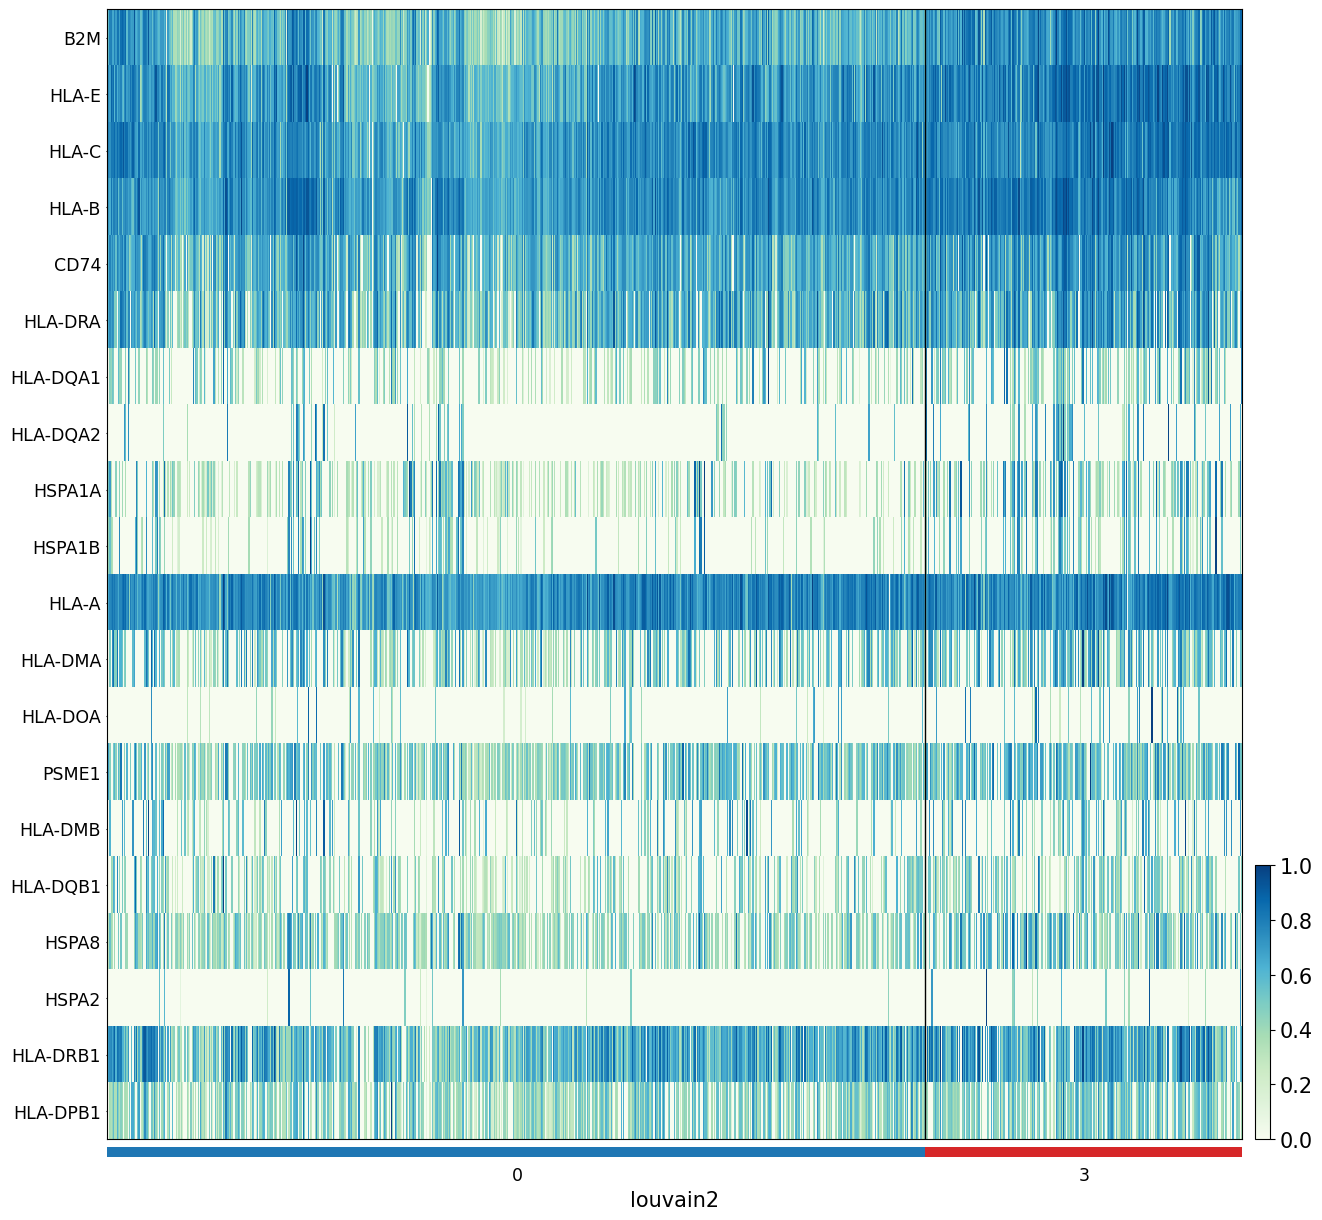

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['image.cmap'] = 'GnBu'
sc.pl.heatmap(adata[(adata.obs.louvain2 == '0') | (adata.obs.louvain2 == '3')],
              list(res_kegg.res2d[res_kegg.res2d.Term.str.contains('KEGG_ANTIGEN_PROCESSING_AND_PRESENTATION')].Lead_genes.str.split(';'))[0],
              groupby='louvain2', standard_scale='var', vmax=1, swap_axes=True,
              figsize=[15,15], show_gene_labels=True)

GSEA with GO database to infer differences between clusters

In [ ]:
if not os.path.exists('go_pathways.gmt'):
    !wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1TaTPb9Kp6qFJPIJI_mtECNex1DLXxe92' -O go_pathways.gmt

--2024-05-13 12:55:03--  https://docs.google.com/uc?export=download&id=1TaTPb9Kp6qFJPIJI_mtECNex1DLXxe92
Resolving docs.google.com (docs.google.com)... 173.194.215.102, 173.194.215.139, 173.194.215.138, ...
Connecting to docs.google.com (docs.google.com)|173.194.215.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1TaTPb9Kp6qFJPIJI_mtECNex1DLXxe92&export=download [following]
--2024-05-13 12:55:04--  https://drive.usercontent.google.com/download?id=1TaTPb9Kp6qFJPIJI_mtECNex1DLXxe92&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.107.132, 2607:f8b0:400c:c0a::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.107.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1380288 (1.3M) [application/octet-stream]
Saving to: ‘go_pathways.gmt’

go_pathways.gmt     100%[===================>]   1.32M  --.-KB

In [ ]:
res_go = gp.gsea(data = matrix,
                   gene_sets='./go_pathways.gmt',
                   cls=list(celltypes),
                   permutation_num=100,
                   permutation_type='phenotype',
                   outdir=None,
                   method='s2n',
                   threads=4)

In [ ]:
res_go.res2d.sort_values('NES', ascending = False)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,gsea,Gene Expression (GO:0010467),0.730521,3.4963,0.0,0.0,0.0,81/273,2.09%,RPS6;RPS24;RPS8;RPS18;RPL7A;RPS19;RPLP1;RPS3;E...
1,gsea,Translation (GO:0006412),0.779817,3.353739,0.0,0.0,0.0,88/211,5.72%,RPS6;RPS24;RPS8;RPS18;RPL7A;RPS19;RPLP1;RPS3;E...
2,gsea,Macromolecule Biosynthetic Process (GO:0009059),0.82235,3.353545,0.0,0.0,0.0,90/166,7.20%,RPS6;RPS24;RPS8;RPS18;RPL7A;RPS19;RPLP1;RPS3;E...
3,gsea,Peptide Biosynthetic Process (GO:0043043),0.859384,3.238456,0.0,0.0,0.0,76/140,2.07%,RPS6;RPS24;RPS8;RPS18;RPL7A;RPS19;RPLP1;RPS3;E...
4,gsea,Ribonucleoprotein Complex Biogenesis (GO:0022613),0.719039,3.026843,0.0,0.0,0.0,48/113,12.04%,RPS6;RPS24;RPS8;RPS19;RPS7;RPS17;RPL5;RPS23;RP...
...,...,...,...,...,...,...,...,...,...,...
62,gsea,Prostaglandin Metabolic Process (GO:0006693),-0.609545,-2.249221,0.0,0.0,0.0,5/24,6.72%,HPGD;CD74;GSTA1;TBXAS1;AKR1C2
58,gsea,Antigen Processing And Presentation Of Endogen...,-0.765963,-2.269057,0.0,0.0,0.0,7/19,5.50%,HLA-E;HLA-C;HLA-B;HLA-DRA;HLA-A;MICA;HLA-DRB1
41,gsea,Icosanoid Metabolic Process (GO:0006690),-0.575545,-2.320872,0.0,0.0,0.0,10/32,7.63%,HPGD;PLA2G4C;DPEP2;LTC4S;EPHX1;ABCC10;CYP4F12;...
34,gsea,Regulation Of T Cell Mediated Cytotoxicity (GO...,-0.656957,-2.36475,0.0,0.0,0.0,8/29,8.32%,HLA-E;HLA-C;HLA-B;HLA-DRA;HLA-A;MICA;HLA-DRB1;...


In [ ]:
res_go.res2d = res_go.res2d[res_go.res2d['FWER p-val'] < 0.05].sort_values('NES', ascending = False)

In [ ]:
res_go.res2d.tail(30)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
63,gsea,Negative Regulation Of Multicellular Organisma...,0.419718,2.247068,0.0,0.001451,0.02,74/184,25.28%,RGCC;GJA1;NPR3;RPS19;LAMA4;NFIB;GAS6;ARHGDIB;F...
64,gsea,Positive Regulation Of Leukocyte Migration (GO...,0.658483,2.24594,0.0,0.001427,0.02,7/24,5.73%,PLVAP;LYVE1;LGALS3;THY1;MDK;IL6;ZNF580
65,gsea,Positive Regulation Of Macromolecule Metabolic...,0.420096,2.245758,0.0,0.001404,0.02,101/264,24.29%,RDX;RGCC;GJA1;IL33;CD36;RPS3;RPS7;RPL5;ACTG1;C...
66,gsea,"RNA Splicing, Via Transesterification Reaction...",0.413132,2.241431,0.0,0.001381,0.02,78/170,35.58%,HNRNPA1;SNRPE;SNRPF;HNRNPC;PABPC1;WBP4;HNRNPM;...
67,gsea,Positive Regulation Of Cell Migration (GO:0030...,0.421738,2.235184,0.0,0.001359,0.02,99/230,28.38%,ENPP2;RDX;INSR;EDN1;ITGA6;FAM107A;F2R;CXCR4;KI...
68,gsea,Platelet Aggregation (GO:0070527),0.622368,2.23199,0.0,0.001561,0.03,12/29,15.74%,HSPB1;ACTG1;GNAS;MYL9;FLNA;MYH9;PPIA;PIK3CB;RA...
69,gsea,Epithelial Tube Morphogenesis (GO:0060562),0.616126,2.229511,0.0,0.001537,0.03,10/27,10.37%,COL4A1;BMP4;PRKD2;PRKX;SOX17;MET;PODXL;SCRIB;P...
70,gsea,Bone Development (GO:0060348),0.605253,2.228933,0.0,0.001513,0.03,8/32,7.86%,GJA1;RPL13;TGM2;GNAS;CYP26B1;TP53;PPIB;STC1
71,gsea,Positive Regulation Of Cell Motility (GO:2000147),0.446523,2.223655,0.0,0.001491,0.03,85/184,28.38%,RDX;INSR;EDN1;ITGA6;FAM107A;F2R;CXCR4;KIT;LAMB...
72,gsea,Heart Trabecula Morphogenesis (GO:0061384),0.682451,2.220374,0.0,0.001469,0.03,6/15,10.80%,ENG;HEY1;TEK;NOTCH1;FKBP1A;TGFBR1


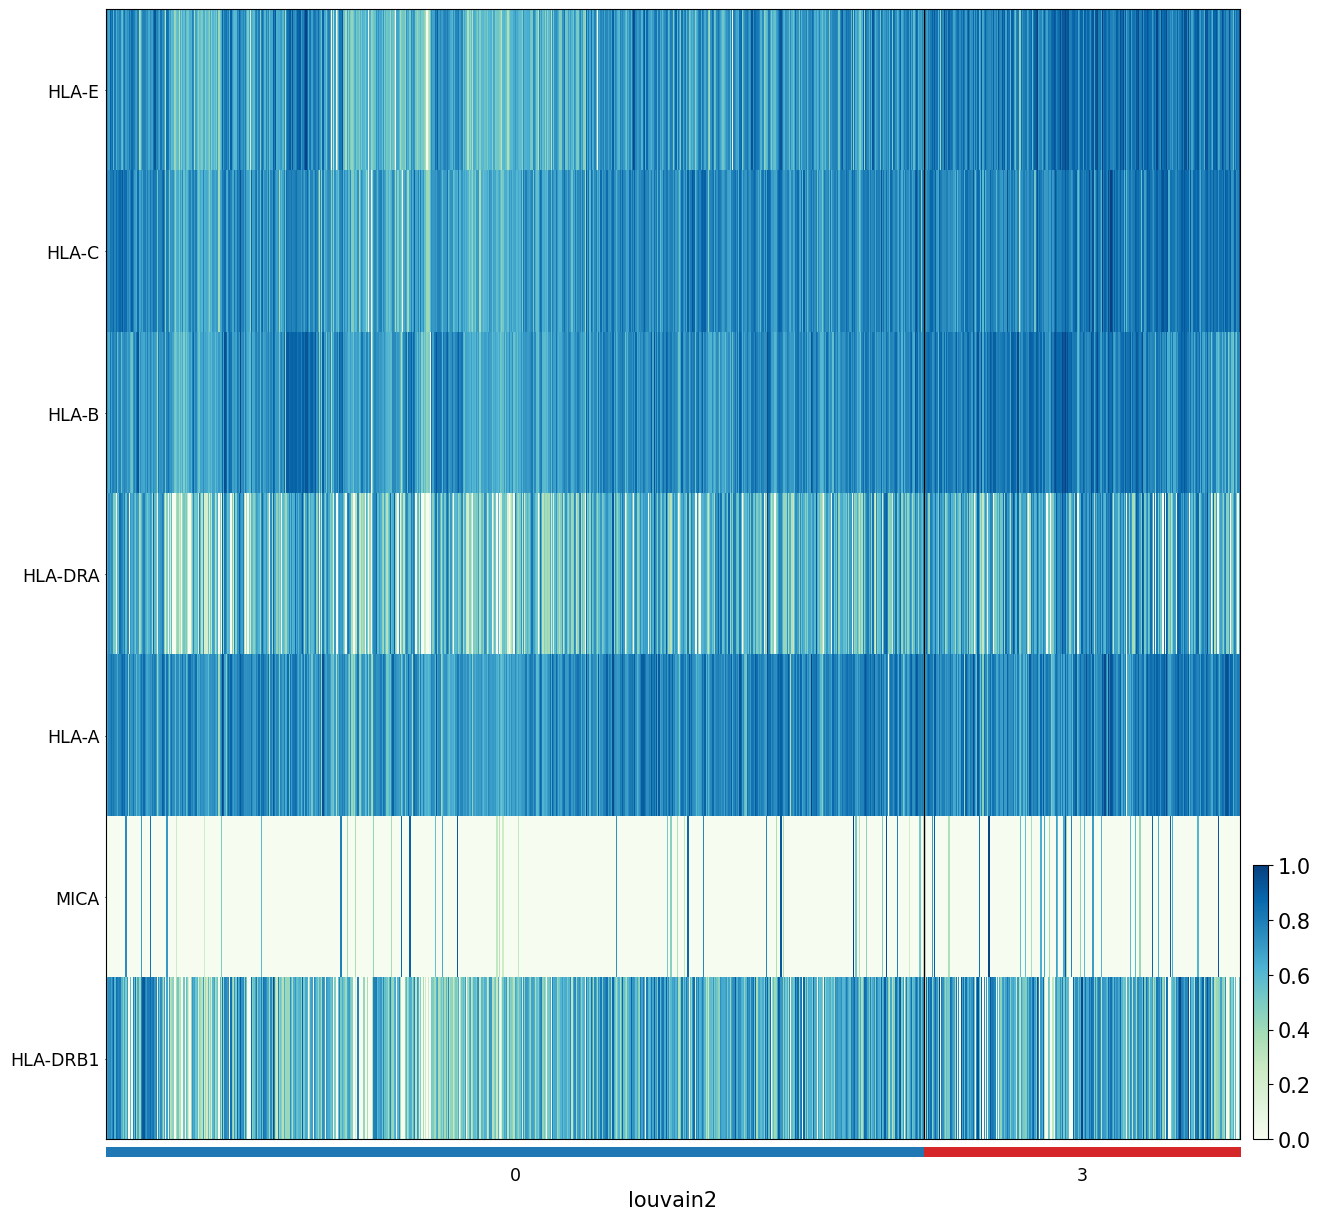

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['image.cmap'] = 'GnBu'
sc.pl.heatmap(adata[(adata.obs.louvain2 == '0') | (adata.obs.louvain2 == '3')],
              list(res_go.res2d[res_go.res2d.Term.str.contains('Antigen Processing And Presentation Of Endo')].Lead_genes.str.split(';'))[0],
              groupby='louvain2', standard_scale='var', vmax=1, swap_axes=True,
              figsize=[15,15], show_gene_labels=True)

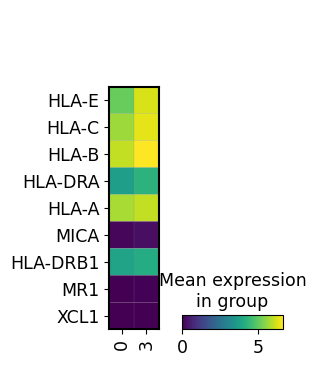

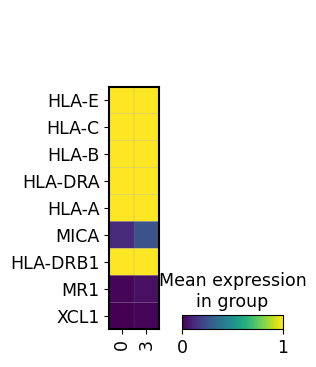

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['image.cmap'] = 'GnBu'

sc.pl.matrixplot(adata[(adata.obs.louvain2 == '0') | (adata.obs.louvain2 == '3')],
                 list(res_go.res2d[res_go.res2d.Term.str.contains('Positive Regulation Of T Cell Mediated Cytotox')].Lead_genes.str.split(';'))[0],
                 groupby='louvain2', swap_axes=True)

sc.pl.matrixplot(adata[(adata.obs.louvain2 == '0') | (adata.obs.louvain2 == '3')],
                 list(res_go.res2d[res_go.res2d.Term.str.contains('Positive Regulation Of T Cell Mediated Cytotox')].Lead_genes.str.split(';'))[0],
                 groupby='louvain2', swap_axes=True, vmax = 1)

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['image.cmap'] = 'GnBu'

sc.pl.matrixplot(adata[(adata.obs.louvain2 == '0') | (adata.obs.louvain2 == '3')],
                 list(res_go.res2d[res_go.res2d.Term.str.contains('0001570')].Lead_genes.str.split(';'))[0],
                 groupby='louvain2', swap_axes=True)

sc.pl.matrixplot(adata[(adata.obs.louvain2 == '0') | (adata.obs.louvain2 == '3')],
                 list(res_go.res2d[res_go.res2d.Term.str.contains('0001570')].Lead_genes.str.split(';'))[0],
                 groupby='louvain2', swap_axes=True, vmax = 1)

IndexError: list index out of range

GSEA to infer differences between Conditions

In [ ]:
adata.obs

In [ ]:
matrix = adata[(adata.obs['origin']=='nLung')| (adata.obs['origin']=='tLung')].to_df().T
celltypes = adata[(adata.obs['origin']=='nLung')| (adata.obs['origin']=='tLung')].obs.origin

In [ ]:
res_go = gp.gsea(data = matrix,
                 gene_sets='./go_pathways.gmt',
                 cls=list(celltypes),
                 permutation_num=100,
                 permutation_type='phenotype',
                 outdir=None,
                 method='s2n',
                 threads=4)

In [ ]:
res_go.res2d = res_go.res2d[res_go.res2d['FWER p-val'] < 0.05].sort_values('NES', ascending = False)

In [ ]:
res_go.res2d.tail(30)

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['image.cmap'] = 'GnBu'

sc.pl.matrixplot(adata[(adata.obs['origin']=='nLung')| (adata.obs['origin']=='tLung')],
                 list(res_go.res2d[res_go.res2d.Term.str.contains('0050853')].Lead_genes.str.split(';'))[0],
                 groupby='origin', swap_axes=True)

sc.pl.matrixplot(adata[(adata.obs['origin']=='nLung')| (adata.obs['origin']=='tLung')],
                 list(res_go.res2d[res_go.res2d.Term.str.contains('0050853')].Lead_genes.str.split(';'))[0],
                 groupby='origin', swap_axes=True, vmax = 1)